In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import t, levene, f_oneway, mannwhitneyu, variation
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# ------------------------------------------------------------
# 1. Загрузка данных
# ------------------------------------------------------------
df_transformers = pd.read_excel('TRANSFORMERS_TEST.xlsx', sheet_name='Sheet1')
df_vllm = pd.read_excel('VLLM_TEST.xlsx', sheet_name='Sheet1')

# Добавляем колонку с меткой модели
df_transformers['model'] = 'Transformers'
df_vllm['model'] = 'VLLM'

In [3]:
# Объединяем
df = pd.concat([df_transformers, df_vllm], ignore_index=True)

# Очистка: удаляем строки с явно некорректными значениями (например, tokens_per_second < 1 или > 1000 - выбросы)
df = df[(df['Tokens per second'] > 1) & (df['Tokens per second'] < 300)]
# Убираем нулевое время ответа
df = df[df['Response times'] > 0]

print(f"Всего наблюдений: {len(df)}")
print(df.groupby('model').size())

Всего наблюдений: 210
model
Transformers    105
VLLM            105
dtype: int64


In [4]:
# ------------------------------------------------------------
# 2. Описательные статистики и доверительные интервалы
# ------------------------------------------------------------
def ci_mean(data, confidence=0.95):
    """Доверительный интервал для среднего (t-распределение)"""
    a = 1.0 * np.array(data)
    n = len(a)
    m, se = np.mean(a), stats.sem(a)
    h = se * t.ppf((1 + confidence) / 2., n-1)
    return m, m-h, m+h

def ci_median_bootstrap(data, confidence=0.95, n_bootstrap=10000):
    """Доверительный интервал для медианы бутстрепом"""
    medians = [np.median(np.random.choice(data, len(data), replace=True)) for _ in range(n_bootstrap)]
    lower = np.percentile(medians, (1-confidence)/2 * 100)
    upper = np.percentile(medians, (1+confidence)/2 * 100)
    return np.median(data), lower, upper

In [5]:
# Анализируем метрику "Tokens per second" (скорость генерации)
print("\n===== Анализ скорости (Tokens per second) =====")
for model in ['Transformers', 'VLLM']:
    data = df[df['model'] == model]['Tokens per second'].dropna()
    mean, ci_low, ci_high = ci_mean(data)
    median, med_low, med_high = ci_median_bootstrap(data)
    cv = variation(data)  # коэффициент вариации
    q95 = np.percentile(data, 95)
    outliers = data[data > q95].count()
    
    print(f"\n--- {model} ---")
    print(f"  Среднее: {mean:.2f} (95% ДИ: [{ci_low:.2f}, {ci_high:.2f}])")
    print(f"  Медиана: {median:.2f} (95% ДИ: [{med_low:.2f}, {med_high:.2f}])")
    print(f"  Коэффициент вариации (CV): {cv:.3f}")
    print(f"  95-й перцентиль: {q95:.2f}")
    print(f"  Доля ответов выше 95-го перцентиля: {outliers}/{len(data)} = {outliers/len(data)*100:.1f}%")



===== Анализ скорости (Tokens per second) =====

--- Transformers ---
  Среднее: 19.91 (95% ДИ: [18.16, 21.65])
  Медиана: 13.95 (95% ДИ: [13.23, 18.02])
  Коэффициент вариации (CV): 0.452
  95-й перцентиль: 39.47
  Доля ответов выше 95-го перцентиля: 6/105 = 5.7%

--- VLLM ---
  Среднее: 99.09 (95% ДИ: [99.06, 99.12])
  Медиана: 99.14 (95% ДИ: [99.12, 99.17])
  Коэффициент вариации (CV): 0.002
  95-й перцентиль: 99.26
  Доля ответов выше 95-го перцентиля: 6/105 = 5.7%


In [6]:
# ------------------------------------------------------------
# 3. Проверка нормальности распределения
# ------------------------------------------------------------
print("\n===== Проверка нормальности (Shapiro-Wilk) =====")
for model in ['Transformers', 'VLLM']:
    data = df[df['model'] == model]['Tokens per second'].dropna()
    stat, p = stats.shapiro(data)
    print(f"{model}: W={stat:.3f}, p-value={p:.4f} – {'Нормальное' if p>0.05 else 'НЕ нормальное'}")


===== Проверка нормальности (Shapiro-Wilk) =====
Transformers: W=0.785, p-value=0.0000 – НЕ нормальное
VLLM: W=0.846, p-value=0.0000 – НЕ нормальное


In [9]:
# ------------------------------------------------------------
# 4. Сравнение дисперсий (ключевая часть гипотезы)
# ------------------------------------------------------------
print("\n===== Сравнение вариабельности =====")
t_data = df[df['model'] == 'Transformers']['Tokens per second'].dropna()
v_data = df[df['model'] == 'VLLM']['Tokens per second'].dropna()

# Тест Левена на равенство дисперсий
lev_stat, lev_p = levene(t_data, v_data)
print(f"Тест Левена: статистика={lev_stat:.3f}, p-value={lev_p:.4f}")
if lev_p < 0.05:
    print("  → Дисперсии значимо различаются (p<0.05). VLLM имеет другую вариабельность.")
else:
    print("  → Дисперсии статистически не различаются.")

# F-тест для отношения дисперсий (требует нормальности, но для иллюстрации)
f_stat = np.var(t_data, ddof=1) / np.var(v_data, ddof=1)
f_p = stats.f.cdf(f_stat, len(t_data)-1, len(v_data)-1) * 2
print(f"F-тест (отношение дисперсий): {f_stat:.3f}, p-value={min(f_p, 1-f_p):.4f}")


# Сравнение коэффициентов вариации (бутстрепом)
cv_t = variation(t_data)
cv_v = variation(v_data)
print(f"Коэффициент вариации: Transformers={cv_t:.3f}, VLLM={cv_v:.3f}")


===== Сравнение вариабельности =====
Тест Левена: статистика=67.293, p-value=0.0000
  → Дисперсии значимо различаются (p<0.05). VLLM имеет другую вариабельность.
F-тест (отношение дисперсий): 2808.126, p-value=-1.0000
Коэффициент вариации: Transformers=0.452, VLLM=0.002


In [11]:
# ------------------------------------------------------------
# 5. Сравнение средних (непараметрический тест, т.к. распределение ненормальное)
# ------------------------------------------------------------
print("\n===== Сравнение средних (Mann-Whitney U) =====")
u_stat, mw_p = mannwhitneyu(t_data, v_data, alternative='two-sided')
print(f"Mann-Whitney U: p-value = {mw_p:.6f}")
if mw_p < 0.05:
    print("  → Средние скорости значимо различаются.")
else:
    print("  → Средние скорости статистически не различаются.")


===== Сравнение средних (Mann-Whitney U) =====
Mann-Whitney U: p-value = 0.000000
  → Средние скорости значимо различаются.


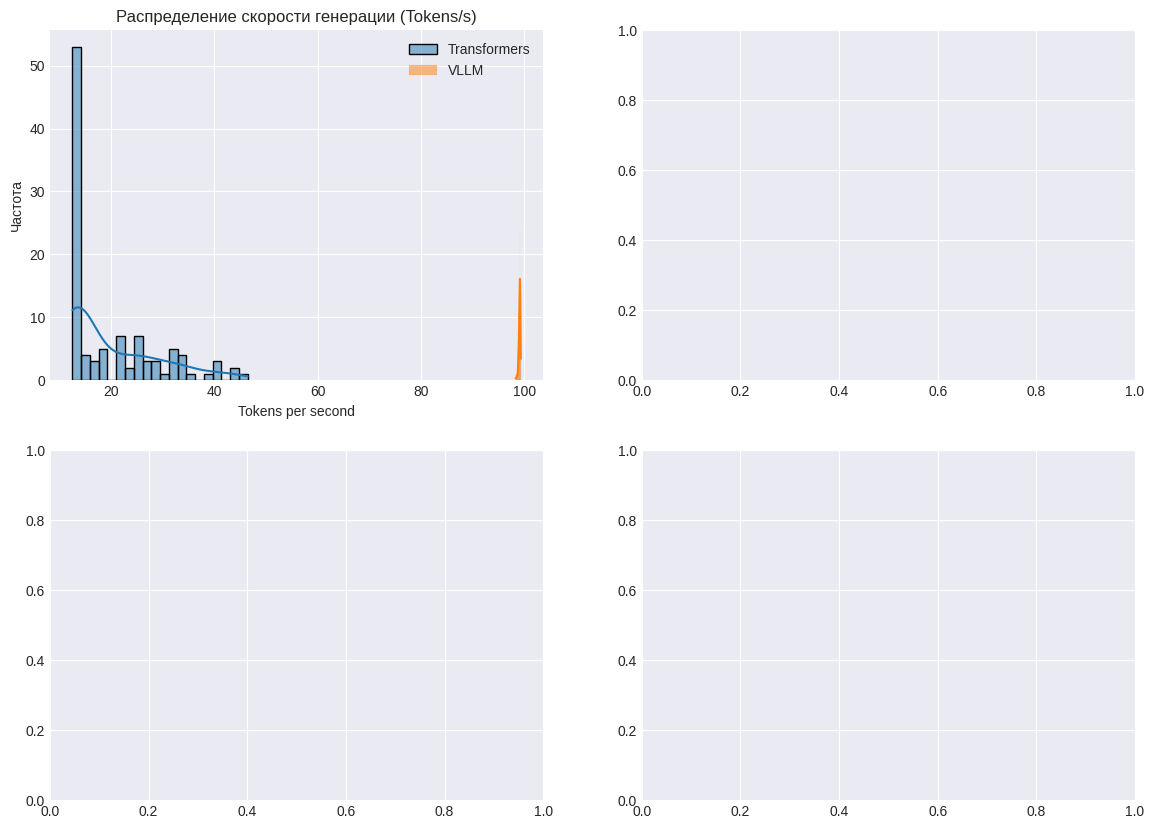

In [12]:
# ------------------------------------------------------------
# 6. Визуализация
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 6.1 Гистограммы + плотность
ax = axes[0,0]
for model, color in zip(['Transformers', 'VLLM'], ['#1f77b4', '#ff7f0e']):
    data = df[df['model'] == model]['Tokens per second']
    sns.histplot(data, bins=20, kde=True, label=model, color=color, alpha=0.5, ax=ax)
ax.set_title('Распределение скорости генерации (Tokens/s)')
ax.set_xlabel('Tokens per second')
ax.set_ylabel('Частота')
ax.legend()

In [13]:
# 6.2 Boxplot с наложением точек
ax = axes[0,1]
sns.boxplot(data=df, x='model', y='Tokens per second', palette='Set2', ax=ax)
sns.stripplot(data=df, x='model', y='Tokens per second', color='black', alpha=0.3, ax=ax)
ax.set_title('Boxplot скорости генерации')

Text(0.5, 1.0, 'Boxplot скорости генерации')

In [15]:
# 6.3 Доверительные интервалы для среднего и медианы
ax = axes[1,0]
means, ci_low_m, ci_high_m = [], [], []
medians, ci_low_med, ci_high_med = [], [], []
for model in ['Transformers', 'VLLM']:
    data = df[df['model'] == model]['Tokens per second']
    m, l, h = ci_mean(data)
    means.append(m); ci_low_m.append(l); ci_high_m.append(h)
    med, lmed, hmed = ci_median_bootstrap(data)
    medians.append(med); ci_low_med.append(lmed); ci_high_med.append(hmed)
x_pos = [0, 1]
ax.errorbar(x_pos, means, yerr=[np.subtract(means, ci_low_m), np.subtract(ci_high_m, means)],
            fmt='o', capsize=10, label='Среднее (95% ДИ)', color='darkblue', markersize=8)
ax.errorbar(x_pos, medians, yerr=[np.subtract(medians, ci_low_med), np.subtract(ci_high_med, medians)],
            fmt='s', capsize=10, label='Медиана (95% ДИ)', color='darkred', markersize=8)
ax.set_xticks(x_pos)
ax.set_xticklabels(['Transformers', 'VLLM'])
ax.set_ylabel('Tokens per second')
ax.set_title('Доверительные интервалы для среднего и медианы')
ax.legend()
ax.grid(axis='y')

In [16]:
# 6.4 Коэффициент вариации
ax = axes[1,1]
cvs = [variation(df[df['model'] == model]['Tokens per second']) for model in ['Transformers', 'VLLM']]
ax.bar(['Transformers', 'VLLM'], cvs, color=['#1f77b4', '#ff7f0e'])
ax.set_ylabel('Коэффициент вариации (CV)')
ax.set_title('Вариабельность скорости (чем ниже, тем предсказуемее)')
for i, cv in enumerate(cvs):
    ax.text(i, cv + 0.01, f'{cv:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('statistical_analysis.png', dpi=150)
plt.show()

<Figure size 1200x600 with 0 Axes>

In [17]:
overall_95 = np.percentile(df['Tokens per second'], 95)
print(f"\n===== Анализ 'медленных' ответов (ниже {overall_95:.1f} tokens/s) =====")
for model in ['Transformers', 'VLLM']:
    data = df[df['model'] == model]['Tokens per second']
    slow_ratio = (data < overall_95).mean()
    print(f"{model}: доля медленных ответов = {slow_ratio*100:.1f}%")


===== Анализ 'медленных' ответов (ниже 99.2 tokens/s) =====
Transformers: доля медленных ответов = 100.0%
VLLM: доля медленных ответов = 89.5%
